In [1]:
!pip install opendatasets
!pip install kaggle

import opendatasets as od
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [2]:
dataset_url = "https://www.kaggle.com/datasets/mohamedhanyyy/chest-ctscan-images"

od.download(dataset_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: chiranjitsahu
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/mohamedhanyyy/chest-ctscan-images


100%|██████████| 119M/119M [00:00<00:00, 1.66GB/s]

In [3]:
train_folder = "/content/chest-ctscan-images/Data/train"
test_folder = "/content/chest-ctscan-images/Data/test"
validate_folder = "/content/chest-ctscan-images/Data/valid"

In [4]:
IMAGE_SIZE = (224,224)
batch_size = 8

train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=10
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_folder,
    target_size=IMAGE_SIZE,
    batch_size=batch_size,
    class_mode='categorical'
)

validation_generator = test_datagen.flow_from_directory(
    validate_folder,
    target_size=IMAGE_SIZE,
    batch_size=batch_size,
    class_mode='categorical'
)

Found 613 images belonging to 4 classes.
Found 72 images belonging to 4 classes.


In [5]:
base_model = Xception(weights='imagenet', include_top=False, input_shape=(224,224,3))

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 111, 111,  │        864 │ input_layer[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 111, 111,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 111, 111,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 109, 109,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 109, 109,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 109, 109,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 109, 109,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 109, 109,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 109, 109,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 109, 109,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 109, 109,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 55, 55,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 55, 55,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 55, 55,    │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 55, 55,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 55, 55,    │          0 │ add[0][0]       

 Total params: 21,124,268 (80.58 MB)

 Trainable params: 21,069,740 (80.37 MB)

 Non-trainable params: 54,528 (213.00 KB)

In [6]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 103s 628ms/step - accuracy: 0.4219 - loss: 1.2472 - val_accuracy: 0.5278 - val_loss: 1.5250
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 12s 160ms/step - accuracy: 0.6874 - loss: 0.8345 - val_accuracy: 0.3750 - val_loss: 1.8769
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 13s 162ms/step - accuracy: 0.7480 - loss: 0.6836 - val_accuracy: 0.6389 - val_loss: 4.2490
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 13s 165ms/step - accuracy: 0.7777 - loss: 0.6027 - val_accuracy: 0.3611 - val_loss: 9.1479
Epoch 5/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 13s 164ms/step - accuracy: 0.8317 - loss: 0.4854 - val_accuracy: 0.6111 - val_loss: 3.9768
Epoch 6/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 13s 163ms/step - accuracy: 0.8456 - loss: 0.4125 - val_accuracy: 0.6111 - val_loss: 1.6206
Epoch 7/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 13s 163ms/step - accuracy: 0.8399 - loss: 0.3900 - val_accuracy: 0.5694 - val_loss: 3.4704
Epoch 8/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 13s 163ms/step - accuracy: 0.8737 - loss: 0.3494 - val_acc

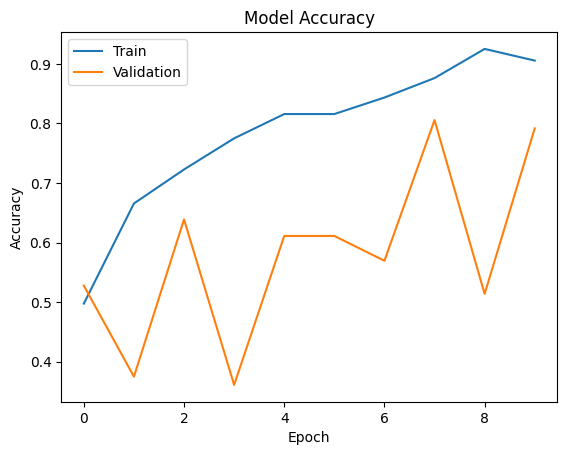

In [7]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()


Using sample image: /content/chest-ctscan-images/Data/test/normal/8 (2) - Copy.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step

===== Prediction Result =====
Detected Condition : normal
Confidence : 100.0 %


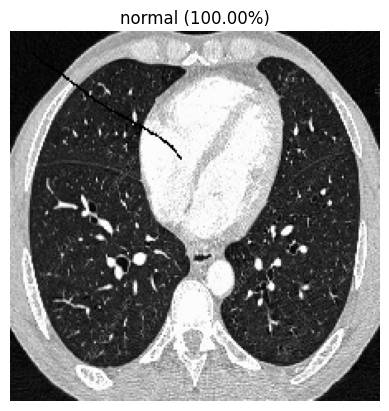

In [8]:
from tensorflow.keras.preprocessing import image
import os
import numpy as np
import matplotlib.pyplot as plt

# Get class names automatically from dataset (these are the labels for predictions)
class_names = list(train_generator.class_indices.keys())

# Get the actual subdirectory names present in the test_folder
# These are the actual class folders on the disk.
actual_test_subdirs = [f.name for f in os.scandir(test_folder) if f.is_dir()]

if actual_test_subdirs:
    # Use the first actual subdirectory found in the test folder
    chosen_class_dir = actual_test_subdirs[0]
    first_class_folder_path = os.path.join(test_folder, chosen_class_dir)

    image_files = os.listdir(first_class_folder_path)

    if image_files:

        sample_image_path = os.path.join(first_class_folder_path, image_files[0])
        print("Using sample image:", sample_image_path)

        img = image.load_img(sample_image_path, target_size=(224,224))
        img_array = image.img_to_array(img)/255
        img_array = np.expand_dims(img_array, axis=0)

        prediction = model.predict(img_array)

        predicted_index = np.argmax(prediction)
        predicted_class = class_names[predicted_index] # Use the original class_names for interpretation
        confidence = np.max(prediction) * 100

        print("\n===== Prediction Result =====")
        print("Detected Condition :", predicted_class)
        print("Confidence :", round(confidence,2), "%")

        # show image
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"{predicted_class} ({confidence:.2f}%)")
        plt.show()

    else:
        print("No image found in:", first_class_folder_path)

else:
    print("No class folders found directly in:", test_folder)

In [9]:
label_map = {
    "adenocarcinoma": "Adenocarcinoma Lung Cancer",
    "large.cell.carcinoma": "Large Cell Lung Cancer",
    "normal": "Healthy Lung",
    "squamous.cell.carcinoma": "Squamous Cell Lung Cancer"
}

Please upload the image file you want to predict on (e.g., ctscan_input.jpg):


Saving ctscan_input.jpg to ctscan_input.jpg
Uploaded file: ctscan_input.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step

===== Prediction Result =====
Detected Condition: Healthy Lung
Confidence: 99.99 %


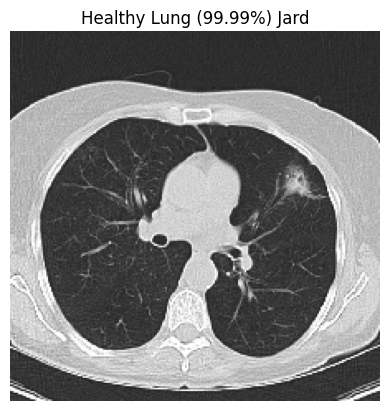

In [10]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files # Import files module

# get class names
class_names = list(train_generator.class_indices.keys())

# readable labels
label_map = {
    "adenocarcinoma": "Adenocarcinoma Lung Cancer",
    "large.cell.carcinoma": "Large Cell Lung Cancer",
    "normal": "Healthy Lung",
    "squamous.cell.carcinoma": "Squamous Cell Lung Cancer"
}

# Upload your image file here
print("Please upload the image file you want to predict on (e.g., ctscan_input.jpg):")
uploaded = files.upload() # This will open a file upload dialog

# Get the filename of the first uploaded file
if uploaded:
    img_path = list(uploaded.keys())[0]
    print(f"Uploaded file: {img_path}")
else:
    # Handle case where no file is uploaded or user cancels
    print("No file was uploaded. Please upload an image to proceed.")
    # You might want to exit or raise an error here if a file is mandatory
    raise FileNotFoundError("No image file uploaded.")

def predict_uploaded_image(img_path):

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)/255
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)

    predicted_index = np.argmax(prediction)
    predicted_class = class_names[predicted_index]
    confidence = np.max(prediction)*100

    print("\n===== Prediction Result =====")
    print("Detected Condition:", label_map[predicted_class])
    print("Confidence:", round(confidence,2), "%")

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{label_map[predicted_class]} ({confidence:.2f}%) Jard")
    plt.show()

predict_uploaded_image(img_path)
